# LVG Jump Diagnostics: Why the Baseline Diffusion Curve Is Irregular

**Purpose.** This notebook diagnoses the second-derivative discontinuities in the original LVG interpolation before any smoothing optimization is applied. It first reproduces the full baseline LVG jump pattern, then uses a two-interval toy model to develop intuition for the smoothness objective, and finally shows why a two-sigma curve cannot satisfy the complete bid-ask-constrained fitting problem.

**Data used.** ArbFree_calls_strikes.csv contains the arbitrage-free target call prices, and Quotes.csv contains market call bid/ask quotes. The full-LVG nu and sigma arrays in the setup cell are stored outputs from the original LVG calibration.

**Notation.** nu denotes fixed LVG interval boundaries, sigma denotes the piecewise diffusion coefficient, and $J(\theta)=\sum_j \left(C''(\nu_j^+)-C''(\nu_j^-)\right)^2$ measures squared second-derivative jumps.

In [27]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

def calculate_J(R1, R2, S0, theta):
    """Return the sum of squared jumps in C'' for an LVG parameter vector."""
    
    # 1. Slicing the parameters
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1_raw = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2_raw = theta[idx : idx + R2]; idx += R2

    nus1 = torch.cat([nus1, torch.tensor([S0])])

    nus2 = torch.cat([torch.tensor([S0]), nus2])

    # Enforce strict positivity on sigmas using softplus
    sigs1 = torch.nn.functional.softplus(sigs1_raw) + 1e-6
    sigs2 = torch.nn.functional.softplus(sigs2_raw) + 1e-6

    # =========================================================================
    # STAGE 1: Calculate Unit Base Coefficients (Setting lam1 = 1, lam2 = 1)
    # =========================================================================

    # Left Wing Unit Base
    c_v1_unit = []
    dist = nus1[1] - nus1[0]
    s0 = sigs1[0]
    c_v1_unit.append((-torch.exp(-dist/s0), torch.exp(dist/s0)))

    for j in range(R1 - 1):
        value_at_boundary = c_v1_unit[j][0] + c_v1_unit[j][1]
        slope_at_boundary = (1.0/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1[j+2] - nus1[j+1]
        c_v1_unit.append((0.5 * (value_at_boundary - sigs1[j+1]*slope_at_boundary) * torch.exp(-dist/sigs1[j+1]),
                          0.5 * (value_at_boundary + sigs1[j+1]*slope_at_boundary) * torch.exp(dist/sigs1[j+1])))

    # Right Wing Unit Base
    c_v2_unit = [None] * R2
    dist = nus2[-1] - nus2[-2]
    c_v2_unit[-1] = ((torch.exp(dist/sigs2[-1]), -torch.exp(-dist/sigs2[-1])))

    for j in range(R2 - 1, 0, -1):
        value_at_boundary = c_v2_unit[j][0] + c_v2_unit[j][1]
        slope_at_boundary = (1.0/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2[j] - nus2[j-1]
        c_v2_unit[j-1] = (0.5 * (value_at_boundary - sigs2[j-1]*slope_at_boundary) * torch.exp(dist/sigs2[j-1]),
                          0.5 * (value_at_boundary + sigs2[j-1]*slope_at_boundary) * torch.exp(-dist/sigs2[j-1]))

    # Verification of this method to compute c values

    # c_v1_test = []
    # c_v1_test.append((-torch.exp(nus1[0]/sigs1[0]), torch.exp(-nus1[0]/sigs1[0])))
    # for j in range(R1 - 1):
    #     c_v1_test.append((  0.5 * ((1 + sigs1[j+1]/sigs1[j])*c_v1_test[j][0]*torch.exp(-nus1[j+1]/sigs1[j]) + (1 - sigs1[j+1]/sigs1[j])*c_v1_test[j][1]*torch.exp(nus1[j+1]/sigs1[j])) / torch.exp(-nus1[j+1]/sigs1[j+1]),
    #                         0.5 * ((1 - sigs1[j+1]/sigs1[j])*c_v1_test[j][0]*torch.exp(-nus1[j+1]/sigs1[j]) + (1 + sigs1[j+1]/sigs1[j])*c_v1_test[j][1]*torch.exp(nus1[j+1]/sigs1[j])) / torch.exp(nus1[j+1]/sigs1[j+1])))
    # for i in range(R1):
    #     print("old:", (c_v1_test[i][0] * torch.exp(-nus1[i+1]/sigs1[i]),  c_v1_test[i][1] * torch.exp(nus1[i+1]/sigs1[i])))
    #     print("new:", (c_v1_unit[i][0], c_v1_unit[i][1]))

    # c_v2_test = [None] * R2
    # c_v2_test[-1] = (torch.exp(nus2[-1]/sigs2[-1]), -torch.exp(-nus2[-1]/sigs2[-1]))
    # for j in range(R2 - 1, 0, -1):
    #     c_v2_test[j-1] = (  0.5 * ((1 + sigs2[j-1]/sigs2[j])*c_v2_test[j][0]*torch.exp(-nus2[j]/sigs2[j]) + (1 - sigs2[j-1]/sigs2[j])*c_v2_test[j][1]*torch.exp(nus2[j]/sigs2[j])) / torch.exp(-nus2[j]/sigs2[j-1]),
    #                         0.5 * ((1 - sigs2[j-1]/sigs2[j])*c_v2_test[j][0]*torch.exp(-nus2[j]/sigs2[j]) + (1 + sigs2[j-1]/sigs2[j])*c_v2_test[j][1]*torch.exp(nus2[j]/sigs2[j])) / torch.exp(nus2[j]/sigs2[j-1]))
    # for i in range(R2):
    #     print("old:", (c_v2_test[i][0] * torch.exp(-nus2[i]/sigs2[i]),  c_v2_test[i][1] * torch.exp(nus2[i]/sigs2[i])))
    #     print("new:", (c_v2_unit[i][0], c_v2_unit[i][1]))
    

    # =========================================================================
    # STAGE 2: Evaluate Unit Wings at S0 and Solve for Viable Lambdas
    # =========================================================================
    
    # Left wing unit value at S0
    v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1]

    # Right wing unit value at S0
    v2 = c_v2_unit[0][0] + c_v2_unit[0][1]

    # Derivatives at left and right of S0
    Dk_v1 = (1.0/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])

    Dk_v2 = (1.0/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])

    # Define viable lambdas
    lam1 = v2 / (Dk_v1 * v2 - v1 * Dk_v2)

    lam2 = v1 / (Dk_v1 * v2 - v1 * Dk_v2)

    # =========================================================================
    # STAGE 3: Scale Unit Coefficients to Final Viable Coefficients
    # =========================================================================
    c_v1 = [(c1 * lam1, c2 * lam1) for (c1, c2) in c_v1_unit]
    c_v2 = [(c1 * lam2, c2 * lam2) for (c1, c2) in c_v2_unit]

    # Plot graph of curve
    # x = torch.linspace(1150, 1350, 1000)
    # y = []
    # for i in x:
    #     if i <= S0:
    #         index = torch.searchsorted(nus1, i, side = 'left') - 1
    #         dist = nus1[index + 1] - i
    #         y.append((c_v1[index][0] * torch.exp(dist/sigs1[index])  + c_v1[index][1] * torch.exp(-dist/sigs1[index])).item() + S0 - i)
    #     else:
    #         index = torch.searchsorted(nus2, i, side = 'left') - 1
    #         dist = i - nus2[index]
    #         y.append((c_v2[index][0] * torch.exp(-dist/sigs2[index])  + c_v2[index][1] * torch.exp(dist/sigs2[index])).item())

    # plt.plot(x,y)

    # =========================================================================
    # STAGE 4: Calculate Smoothness Jumps
    # =========================================================================
    jumps = []

    # Internal Left Wing Jumps
    for j in range(R1 - 1):
        v_sec_left = (1.0/sigs1[j]**2) * (c_v1[j][0] + c_v1[j][1])
        dist = nus1[j+2] - nus1[j+1]
        v_sec_right = (1.0/sigs1[j+1]**2) * (c_v1[j+1][0]*torch.exp(dist/sigs1[j+1]) +
                                            c_v1[j+1][1]*torch.exp(-dist/sigs1[j+1]))
        jumps.append(v_sec_right - v_sec_left)

    # Junction Jump at x_strike
    v_sec_v1_strike = (1.0/sigs1[-1]**2) * (c_v1[-1][0] + c_v1[-1][1])
    v_sec_v2_strike = (1.0/sigs2[0]**2) * (c_v2[0][0] + c_v2[0][1])
    
    jumps.append(v_sec_v2_strike - v_sec_v1_strike)

    # Internal Right Wing Jumps
    for j in range(R2 - 1):
        v_sec_right = (1.0/sigs2[j+1]**2) * (c_v2[j+1][0] + c_v2[j+1][1])
        dist = nus2[j+1] - nus2[j]
        # Interval j uses sigma_j when it is evaluated at its right endpoint.
        v_sec_left = (1.0/sigs2[j]**2) * (c_v2[j][0]*torch.exp(-dist/sigs2[j]) +
                                            c_v2[j][1]*torch.exp(dist/sigs2[j]))
        jumps.append(v_sec_right - v_sec_left)

    j_val = torch.sum(torch.stack(jumps) ** 2)
    return j_val, lam1, lam2


def compute_jump_diagnostics(R1, R2, S0, theta):
    idx = 0

    nus1 = theta[idx : idx + R1]
    idx += R1

    sigs1_raw = theta[idx : idx + R1]
    idx += R1

    nus2 = theta[idx : idx + R2]
    idx += R2

    sigs2_raw = theta[idx : idx + R2]

    nus1 = torch.cat([nus1, torch.tensor([S0], dtype=theta.dtype)])
    nus2 = torch.cat([torch.tensor([S0], dtype=theta.dtype), nus2])

    sigs1 = torch.nn.functional.softplus(sigs1_raw) + 1e-6
    sigs2 = torch.nn.functional.softplus(sigs2_raw) + 1e-6

    c_v1_unit = []
    dist = nus1[1] - nus1[0]
    c_v1_unit.append((-torch.exp(-dist / sigs1[0]), torch.exp(dist / sigs1[0])))

    for j in range(R1 - 1):
        value_at_boundary = c_v1_unit[j][0] + c_v1_unit[j][1]
        slope_at_boundary = (1.0 / sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1[j + 2] - nus1[j + 1]

        c_v1_unit.append((
            0.5 * (value_at_boundary - sigs1[j + 1] * slope_at_boundary) * torch.exp(-dist / sigs1[j + 1]),
            0.5 * (value_at_boundary + sigs1[j + 1] * slope_at_boundary) * torch.exp( dist / sigs1[j + 1]),
        ))

    c_v2_unit = [None] * R2
    dist = nus2[-1] - nus2[-2]
    c_v2_unit[-1] = (
        torch.exp(dist / sigs2[-1]),
        -torch.exp(-dist / sigs2[-1]),
    )

    for j in range(R2 - 1, 0, -1):
        value_at_boundary = c_v2_unit[j][0] + c_v2_unit[j][1]
        slope_at_boundary = (1.0 / sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2[j] - nus2[j - 1]

        c_v2_unit[j - 1] = (
            0.5 * (value_at_boundary - sigs2[j - 1] * slope_at_boundary) * torch.exp( dist / sigs2[j - 1]),
            0.5 * (value_at_boundary + sigs2[j - 1] * slope_at_boundary) * torch.exp(-dist / sigs2[j - 1]),
        )

    v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1]
    v2 = c_v2_unit[0][0] + c_v2_unit[0][1]

    Dk_v1 = (1.0 / sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])
    Dk_v2 = (1.0 / sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])

    denominator = Dk_v1 * v2 - v1 * Dk_v2

    lam1 = v2 / denominator
    lam2 = v1 / denominator

    c_v1 = [(c1 * lam1, c2 * lam1) for (c1, c2) in c_v1_unit]
    c_v2 = [(c1 * lam2, c2 * lam2) for (c1, c2) in c_v2_unit]

    rows = []

    for j in range(R1 - 1):
        knot = nus1[j + 1]

        left_Cpp = (1.0 / sigs1[j]**2) * (c_v1[j][0] + c_v1[j][1])

        dist = nus1[j + 2] - nus1[j + 1]
        right_Cpp = (1.0 / sigs1[j + 1]**2) * (
            c_v1[j + 1][0] * torch.exp( dist / sigs1[j + 1])
            + c_v1[j + 1][1] * torch.exp(-dist / sigs1[j + 1])
        )

        jump = right_Cpp - left_Cpp

        rows.append({
            "branch": "left",
            "knot": knot.detach().item(),
            "left_Cpp": left_Cpp.detach().item(),
            "right_Cpp": right_Cpp.detach().item(),
            "jump": jump.detach().item(),
            "jump_squared": (jump**2).detach().item(),
        })

    knot = torch.tensor(S0, dtype=theta.dtype)

    left_Cpp = (1.0 / sigs1[-1]**2) * (c_v1[-1][0] + c_v1[-1][1])
    right_Cpp = (1.0 / sigs2[0]**2) * (c_v2[0][0] + c_v2[0][1])

    jump = right_Cpp - left_Cpp

    rows.append({
        "branch": "spot",
        "knot": knot.detach().item(),
        "left_Cpp": left_Cpp.detach().item(),
        "right_Cpp": right_Cpp.detach().item(),
        "jump": jump.detach().item(),
        "jump_squared": (jump**2).detach().item(),
    })

    for j in range(R2 - 1):
        knot = nus2[j + 1]

        dist = nus2[j + 1] - nus2[j]
        left_Cpp = (1.0 / sigs2[j]**2) * (
            c_v2[j][0] * torch.exp(-dist / sigs2[j])
            + c_v2[j][1] * torch.exp(dist / sigs2[j])
        )

        right_Cpp = (1.0 / sigs2[j + 1]**2) * (
            c_v2[j + 1][0] + c_v2[j + 1][1]
        )

        jump = right_Cpp - left_Cpp

        rows.append({
            "branch": "right",
            "knot": knot.detach().item(),
            "left_Cpp": left_Cpp.detach().item(),
            "right_Cpp": right_Cpp.detach().item(),
            "jump": jump.detach().item(),
            "jump_squared": (jump**2).detach().item(),
        })

    diagnostics = pd.DataFrame(rows)
    J_from_table = diagnostics["jump_squared"].sum()

    return diagnostics, J_from_table, lam1.detach().item(), lam2.detach().item()


R1, R2 = 70, 34
S0 = 1271.87

initial_sigs1 = torch.tensor([610.4320996213446, 164.04874695079099, 21.410699478563217, 41.036799095433764, 32.59140099151007, 48.77559067919313, 42.2176372999541, 55.823566769595985, 51.211167181688566, 60.691607330511374, 59.950820637770775, 58.898463641159154, 61.253284806200256, 58.77606559998955, 61.9431978849179, 57.790240203069374, 62.2779153688338, 54.621537161593736, 60.38808834808558, 50.96497274766389, 57.49812984113923, 46.576659253726845, 54.080819207223875, 40.60311710082493, 46.79656147874567, 40.230053767550686, 44.17878499997829, 40.0738197788728, 42.59425882166232, 41.97429249407287, 43.554019179773334, 43.64066412990515, 46.68459597597928, 40.66643248490499, 45.74533322390213, 37.58570160756966, 43.36876861252296, 34.281419881606425, 38.63837902433531, 34.11699307804324, 38.33534468465065, 33.11788846662374, 37.54304297301797, 30.8995436545175, 34.629132576982585, 31.932382438352974, 34.99302768634262, 31.44000481459117, 34.80339761657143, 31.011124152999194, 33.67039062291056, 32.963580616942636, 33.88070107871873, 37.490458108901564, 36.9523875799828, 42.71457754035583, 46.473166992677335, 33.8545330176666, 43.67858033724246, 24.46553767335429, 29.27267842043444, 33.253868886417095, 32.860201483329625, 36.87919843993161, 38.56770262319378, 34.89031672560033, 32.336062185014455, 54.86203086146442, 42.54094598147429, 31.82466458162184])
initial_sigs2 = torch.tensor([24.02631471182734, 38.31350500726014, 64.22160217291687, 24.945880842361603, 31.475272346451945, 31.167940240782592, 29.04149431455202, 30.22926871363152, 28.245473181139502, 27.3473961133823, 26.078699124964757, 24.718907886876814, 23.35903470115683, 22.454368334929534, 22.002320937211316, 19.569326547161026, 19.315256975829875, 17.756271425921597, 19.392408982133873, 39.61543966355491, 26.387286176796366, 49.89596975113815, 28.527769674700764, 31.874820986884167, 41.72362039958813, 83.04797290752168, 40.34143759307382, 37.0089135084597, 39.353339426345215, 30.273572809409785, 73.52830072545393, 57.33057445441953, 169.4372302588361, 313.0441713343745])
initial_nus1 = torch.tensor([0, 985.8952130330157, 1103.9, 1105.6299717509714, 1108.9, 1110.9261114114317, 1113.9, 1116.0803462760916, 1118.9, 1121.217532062242, 1123.9, 1126.4524566940233, 1128.9, 1131.482542383951, 1133.9, 1136.5181574323626, 1138.9, 1141.5955696582002, 1143.9, 1146.6439410206626, 1148.9, 1151.6955052869373, 1153.9, 1156.7899943184998, 1158.9, 1161.6254606809712, 1163.9, 1166.5610218554195, 1168.9, 1171.459730260086, 1173.9, 1176.4403363141735, 1178.9, 1181.615546573849, 1183.9, 1186.6888172217348, 1188.9, 1191.7378244235415, 1193.9, 1196.5483693501587, 1198.8, 1201.5325443234078, 1203.8, 1206.5944516093734, 1208.8, 1211.4560716332721, 1213.8, 1216.4902257056644, 1218.8, 1221.5020603603978, 1223.8, 1226.3861829743955, 1228.8, 1231.2336479134826, 1233.8, 1236.1780621637572, 1238.8, 1241.7477258299014, 1243.8, 1247.0561689330698, 1248.8, 1251.2009300066638, 1253.8, 1256.2167752285077, 1258.8, 1261.4846983461696, 1263.8, 1265.7099860650808, 1268.8, 1270.5770900753105])
initial_nus2 = torch.tensor([1272.6042131350682, 1273.8, 1277.3405408056378, 1278.8, 1281.2353139855318, 1283.8, 1286.1696012675789, 1288.8, 1291.2560021979807, 1293.8, 1296.2794535546955, 1298.8, 1301.213819395613, 1303.7, 1306.2617186435, 1308.7, 1311.232700889095, 1313.7, 1316.810048833819, 1323.7, 1327.0068556961314, 1333.7, 1336.0240360741054, 1338.7, 1343.4698860472697, 1353.7, 1356.277830214803, 1358.7, 1361.5021167401464, 1363.7, 1377.3378359299822, 1388.7, 1503.7243622969859, 2000.0])              
def inverse_softplus(values):
    # Convert positive sigma values to unconstrained parameters used by theta
    values = torch.as_tensor(values, dtype=torch.float64)
    raw = torch.empty_like(values)
    large_values = values > 30.0
    raw[large_values] = values[large_values] + torch.log1p(-torch.exp(-values[large_values]))
    raw[~large_values] = torch.log(torch.expm1(values[~large_values]))
    return raw


sigs1_raw = inverse_softplus(initial_sigs1)
sigs2_raw = inverse_softplus(initial_sigs2)

theta_baseline = torch.cat([
        initial_nus1,
        sigs1_raw,  
        initial_nus2,
        sigs2_raw
    ]).clone().detach().requires_grad_(True)

J_baseline, lam1, lam2 = calculate_J(R1, R2, S0, theta_baseline)

print("Baseline J:", J_baseline.item())
print("lambda 1:", lam1.item())
print("lambda 2:", lam2.item())

baseline_jumps, J_from_table, lam1_diag, lam2_diag = compute_jump_diagnostics(
    R1, R2, S0, theta_baseline
)

print("J from calculate_J:", J_baseline.item())
print("J from diagnostics table:", J_from_table)
print("lambda 1:", lam1_diag)
print("lambda 2:", lam2_diag)

baseline_jumps.head()

Baseline J: 0.0012528862075665398
lambda 1: 0.06128928479023477
lambda 2: 0.14084548102635816
J from calculate_J: 0.0012528862075665398
J from diagnostics table: 0.0012528862075665396
lambda 1: 0.06128928479023477
lambda 2: 0.14084548102635816


,branch,knot,left_Cpp,right_Cpp,jump,jump_squared
0,left,985.895213,7.943342e-07,0.000011,0.000010,1.041243e-10
1,left,1103.900000,1.647370e-05,0.000967,0.000951,9.037064e-07
2,left,1105.629972,9.781224e-04,0.000266,-0.000712,5.067463e-07
3,left,1108.900000,2.744178e-04,0.000435,0.000161,2.580721e-08
4,left,1110.926111,4.447700e-04,0.000199,-0.000246,6.060930e-08


## 1. Baseline LVG second-derivative jumps

### Mathematical Setup

The LVG interpolation is written in terms of call time value

$$V(K)=C(K)-(S_0-K)^+.$$

Away from the strike $S_0$, the intrinsic-value term is linear, so its second derivative is zero. Therefore the jump diagnostic may be computed using either call price or time value:

$$C''(K)=V''(K).$$

The original LVG calibration supplies fixed interval boundaries $\nu_j$ and one diffusion coefficient $\sigma_j$ on each interval. Within an interval, the time-value solution has exponential form. In the local endpoint coordinates stored by the code, it can be written as

$$V_j(K)=a_j e^{-d(K)/\sigma_j}+b_j e^{d(K)/\sigma_j},$$

where $d(K)$ is the distance from the endpoint used for that interval. Differentiating twice gives the important identity

$$V_j''(K)=\frac{1}{\sigma_j^2}\left(a_j e^{-d(K)/\sigma_j}+b_j e^{d(K)/\sigma_j}\right)=\frac{V_j(K)}{\sigma_j^2}.$$

The curve is constructed to match value and first derivative at neighboring pieces, but its second derivative may change discontinuously at an interval boundary.

At knot $\nu_j$, define the jump

$$\Delta_j = C''(\nu_j^+) - C''(\nu_j^-).$$

The smoothness objective is

$$J(\theta) = \sum_j \Delta_j^2,$$

where $\theta$ contains the interval knots and diffusion coefficients. In the code, calculate_J recursively builds the exponential coefficients, evaluates $C''$ from each side of every knot, and sums the squared jumps. The stem plot below displays the individual $\Delta_j$ terms whose squares add to J. Large stems identify the locations responsible for irregularity.

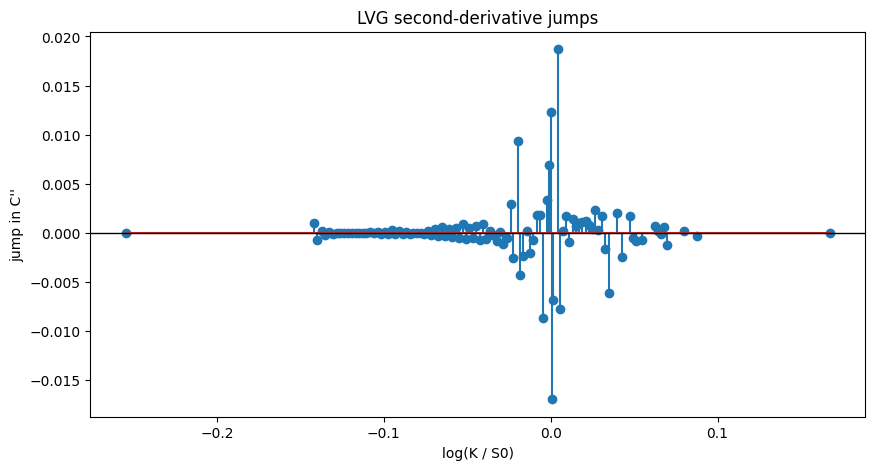

In [28]:
plt.figure(figsize=(10, 5))

x = np.log(baseline_jumps["knot"] / S0)
y = baseline_jumps["jump"]

plt.stem(x, y)
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("log(K / S0)")
plt.ylabel("jump in C''")
plt.title("LVG second-derivative jumps")

plt.show()

## 2. Diffusion coefficient implied by the baseline LVG fit

The LVG diffusion coefficient is piecewise constant:

$$\sigma(K)=\sigma_j \quad \text{for } K\in[\nu_j,\nu_{j+1}).$$

Thus, the graph is constructed by reading the sigma value attached to each interval and drawing that constant value between its two knots. A visually jagged diffusion graph represents large neighboring changes in the local diffusion coefficient.

This is related to, but not identical to, the smoothness objective. The plotted diffusion values are $\sigma_j$, while

$$J(\theta)=\sum_j\left(C''(\nu_j^+)-C''(\nu_j^-)\right)^2$$

measures curvature mismatch in the reconstructed price curve. A small coordinated movement in sigmas can substantially reduce J without making the diffusion plot look dramatically different.

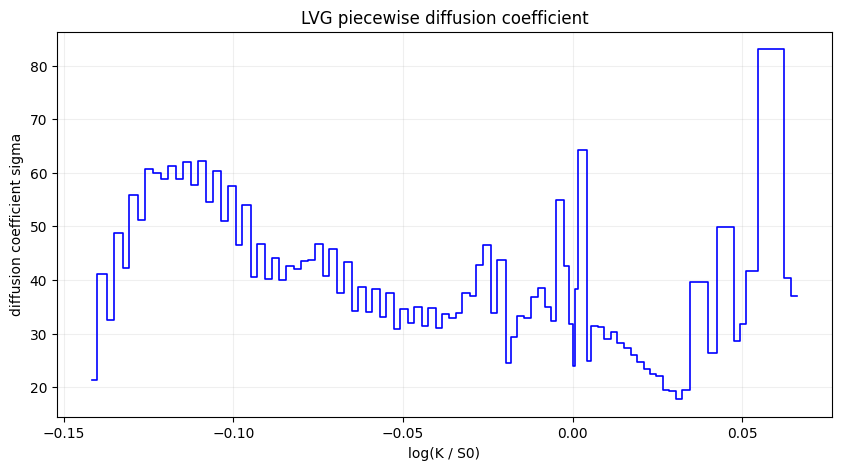

In [29]:
def extract_piecewise_sigmas(R1, R2, S0, theta):
    """Create one table row for each piecewise-constant diffusion interval."""
    ## this was created with codex

    left_nu = theta[0:R1]
    left_raw_sigma = theta[R1:2 * R1]
    right_nu = theta[2 * R1:2 * R1 + R2]
    right_raw_sigma = theta[2 * R1 + R2:2 * R1 + 2 * R2]

    left_knots = torch.cat([left_nu, torch.tensor([S0])])
    right_knots = torch.cat([torch.tensor([S0]), right_nu])
    sigma_left = torch.nn.functional.softplus(left_raw_sigma) + 1e-6
    sigma_right = torch.nn.functional.softplus(right_raw_sigma) + 1e-6

    rows = []
    # appending dictionaries with intervals and sigmas for left and right wings
    for j in range(R1):
        rows.append({"K_left": left_knots[j].item(), "K_right": left_knots[j + 1].item(), "sigma": sigma_left[j].item()})
    for j in range(R2):
        rows.append({"K_left": right_knots[j].item(), "K_right": right_knots[j + 1].item(), "sigma": sigma_right[j].item()})
    return pd.DataFrame(rows)


def plot_piecewise_diffusion(sigma_df, S0, k_min=None, k_max=None):
    df = sigma_df.copy()

    # Remove artificial boundary at K=0
    df = df[df["K_left"] > 0]

    # Optional: restrict to market strike range
    if k_min is not None:
        df = df[df["K_right"] >= k_min]
    if k_max is not None:
        df = df[df["K_left"] <= k_max]

    df = df.sort_values("K_left")

    xs = []
    ys = []

    for _, row in df.iterrows():
        K_left = max(row["K_left"], k_min) if k_min is not None else row["K_left"]
        K_right = min(row["K_right"], k_max) if k_max is not None else row["K_right"]

        if K_left <= 0 or K_right <= 0 or K_right <= K_left:
            continue

        x_left = np.log(K_left / S0)
        x_right = np.log(K_right / S0)

        xs.extend([x_left, x_right])
        ys.extend([row["sigma"], row["sigma"]])

    plt.figure(figsize=(10, 5))
    plt.plot(xs, ys, color="blue", linewidth=1.2)

    plt.xlabel("log(K / S0)")
    plt.ylabel("diffusion coefficient sigma")
    plt.title("LVG piecewise diffusion coefficient")
    plt.grid(alpha=0.2)
    plt.show()


sigma_df = extract_piecewise_sigmas(R1, R2, S0, theta_baseline)

plot_piecewise_diffusion(
    sigma_df,
    S0,
    k_min=1103.9,
    k_max=1358.7,
)

## 3. Two-interval toy diagnostic for the shape of $J$

Before attempting optimization in more than one hundred sigma coordinates, we examine the simplest case: one interval to the left of spot and one interval to the right. The endpoint knots are fixed at $L=0$ and $\bar K=2000$:

$$[0,S_0] \text{ uses } \sigma_{\mathrm{left}}, \qquad [S_0,\bar K] \text{ uses } \sigma_{\mathrm{right}}.$$

There is only one interior joining location, $S_0$. Thus the objective becomes a function of two displayed variables:

$$J(\sigma_{\mathrm{left}},\sigma_{\mathrm{right}})=\left(C''(S_0^+)-C''(S_0^-)\right)^2.$$

For each pixel in the heatmap, the code constructs a two-interval theta, evaluates the same calculate_J function used above, and colors the point by the resulting value of $J$. Dark colors correspond to smoother joining curvature.

This surface is a diagnostic only. It shows how J responds to two diffusion coefficients; it is not expected to fit all market quotes.

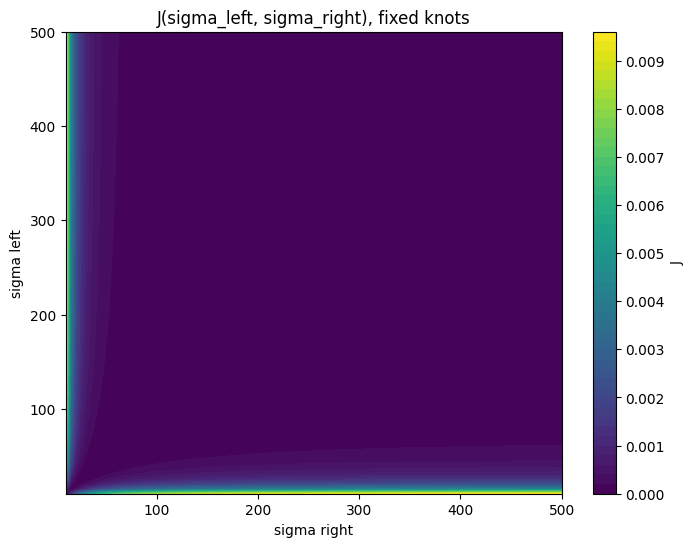

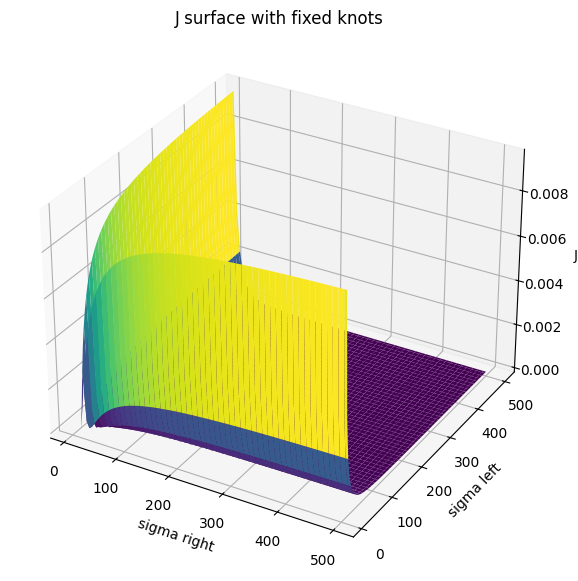

In [30]:
R1_toy = 1
R2_toy = 1

L = 0.0
Kbar = 2000.0

fixed_nu1 = torch.tensor([L], dtype=torch.float64)
fixed_nu2 = torch.tensor([Kbar], dtype=torch.float64)

# Sigma is a diffusion coefficient, so the diagnostic grid begins above zero.
sigma_left_grid = np.linspace(10.0, 500.0, 100)
sigma_right_grid = np.linspace(10.0, 500.0, 100)

J_values = np.zeros((len(sigma_left_grid), len(sigma_right_grid)))

for i, sigma_left in enumerate(sigma_left_grid):
    for j, sigma_right in enumerate(sigma_right_grid):

        sigma_left_raw = inverse_softplus([sigma_left])
        sigma_right_raw = inverse_softplus([sigma_right])

        theta_toy = torch.cat([
            fixed_nu1,
            sigma_left_raw,
            fixed_nu2,
            sigma_right_raw,
        ])

        J_toy, _, _ = calculate_J(R1_toy, R2_toy, S0, theta_toy)

        J_values[i, j] = J_toy.detach().item()



X, Y = np.meshgrid(sigma_right_grid, sigma_left_grid)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, J_values, levels=50)
plt.colorbar(label="J")

plt.xlabel("sigma right")
plt.ylabel("sigma left")
plt.title("J(sigma_left, sigma_right), fixed knots")

plt.show()


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, J_values, cmap="viridis")

ax.set_xlabel("sigma right")
ax.set_ylabel("sigma left")
ax.set_zlabel("J")
ax.set_title("J surface with fixed knots")

plt.show()


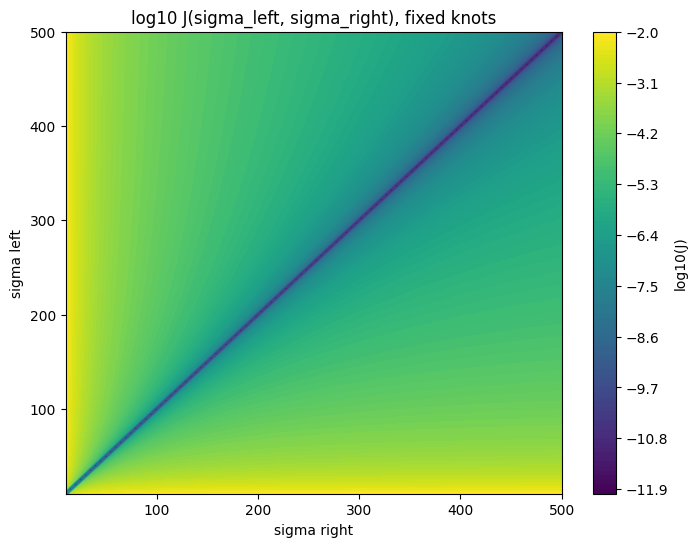

In [31]:
# log plot for clarity on the shape of the surface, since J values can be very small
plt.figure(figsize=(8, 6))

plt.contourf(
    X,
    Y,
    np.log10(J_values + 1e-12),
    levels=100
)

plt.colorbar(label="log10(J)")
plt.xlabel("sigma right")
plt.ylabel("sigma left")
plt.title("log10 J(sigma_left, sigma_right), fixed knots")

plt.show()

## 4. Relating the toy surface to the original LVG calibration

The red point below uses the first two baseline LVG sigmas values on either side of the spot. They are guaranteed to fit all constrainsts. 

The arrays initial_nus1, initial_nus2, initial_sigs1, and initial_sigs2 at the beginning of this notebook are the parameters produced by the original LVG interpolation of the arbitrage-free calls. They are stored explicitly here so this diagnostic notebook is rerunnable without importing hidden state from another notebook.

In [32]:
# These are the two original full-LVG intervals immediately adjacent to spot.
sigma_left_real = initial_sigs1[-1].item()
sigma_right_real = initial_sigs2[0].item()

# .item() is used to extract the scalar value from the tensor for printing

print("sigma left near spot:", sigma_left_real)
print("sigma right near spot:", sigma_right_real)

sigma left near spot: 31.82466458162184
sigma right near spot: 24.02631471182734


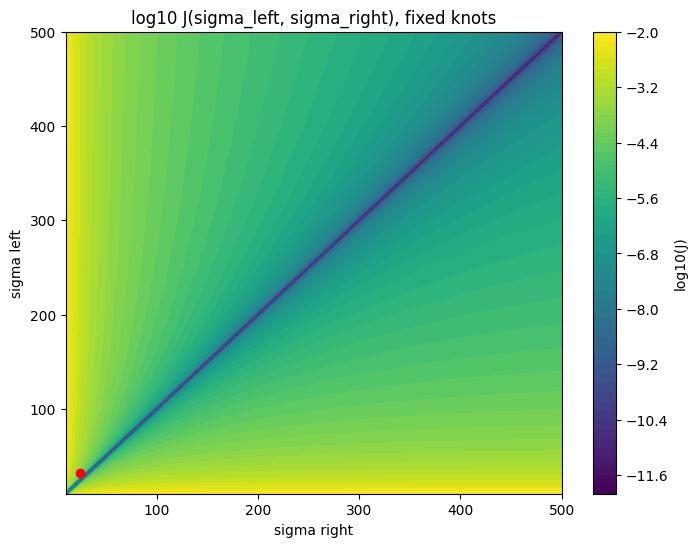

In [33]:
X, Y = np.meshgrid(sigma_right_grid, sigma_left_grid)

plt.figure(figsize=(8, 6))

plt.contourf(
    X,
    Y,
    np.log10(J_values + 1e-12),
    levels=50
)

plt.colorbar(label="log10(J)")
plt.xlabel("sigma right")
plt.ylabel("sigma left")
plt.title("log10 J(sigma_left, sigma_right), fixed knots")
plt.scatter([sigma_right_real], [sigma_left_real], color="red", label="real sigmas")

plt.show()



**Interpretation.** This heatmap is a two-interval diagnostic, not the full LVG optimization problem. In this reduced model there is one diffusion coefficient on the entire left wing and one on the entire right wing, so the only curvature discontinuity occurs at $S_0$. Because the two wings are matched to have the same time value at spot,

$$
\Delta C''(S_0)
=
V(S_0)
\left(
\frac{1}{\sigma_{\mathrm{right}}^2}
-
\frac{1}{\sigma_{\mathrm{left}}^2}
\right),
$$

and therefore $J$ is minimized along the diagonal

$$
\sigma_{\mathrm{left}}=\sigma_{\mathrm{right}}.
$$

The red point is not the full baseline LVG solution. It plots only the two baseline diffusion coefficients on the intervals immediately adjacent to spot:

$$
\sigma_{\mathrm{left}}=31.8247,
\qquad
\sigma_{\mathrm{right}}=24.0263.
$$

Their mismatch implies a nonzero spot curvature jump and helps explain why the full-model jump diagnostics show irregularity near $S_0$. However, this toy plot does not establish that the full LVG curve can move directly to the diagonal while preserving all market-price constraints, because the full model contains many additional intervals and bid-ask restrictions.

Also, you can see that the "minimum" is at the top-right of the contour plot at (500,500). However, this would render the curves essentially flat and would not come even close to holding the constrainsts.

## 5. Arbitrage-free target time-value curve

The LVG interpolation is performed on call time value

$$V(K) = C(K) - (S_0-K)^+.$$

For a call option, intrinsic value is

$$(S_0-K)^+=\max(S_0-K,0).$$

The code reads each arbitrage-free call price $C(K_i)$ and computes

$$V(K_i)=C(K_i)-\max(S_0-K_i,0).$$

Removing intrinsic value isolates the part of the curve modeled by the LVG exponential construction and makes the left and right wings meet at the positive value $V(S_0)$. The blue curve below is the calibration target in time-value coordinates.

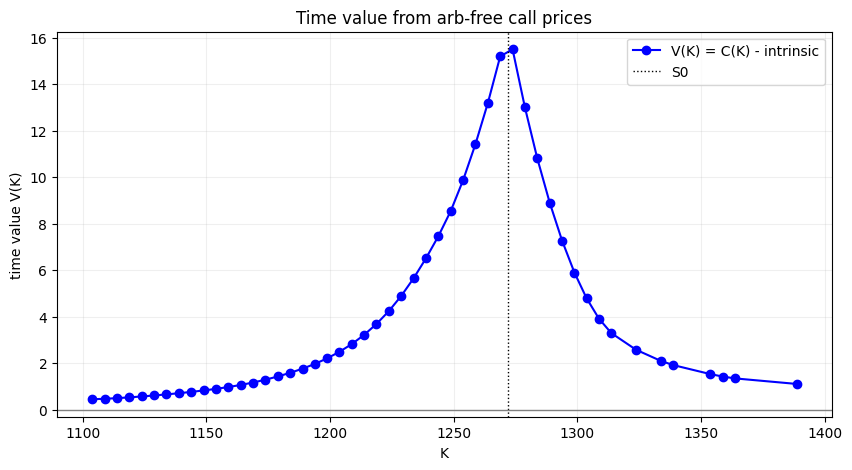

In [34]:
S0 = 1271.87

arb = pd.read_csv(
    "ArbFree_calls_strikes.csv",
    header = None,
    names = ["C", "K"]
)

arb = arb.sort_values("K").reset_index(drop=True)

K = arb["K"].to_numpy(dtype=float)
C = arb["C"].to_numpy(dtype=float)

intrinsic = np.maximum(S0 - K, 0.0)
V = C - intrinsic

arb["intrinsic"] = intrinsic
arb["V"] = V

plt.figure(figsize=(10, 5))

plt.plot(K, V, marker="o", linewidth=1.5, color="blue", label="V(K) = C(K) - intrinsic")

plt.axvline(S0, color="black", linestyle=":", linewidth=1, label="S0")
plt.axhline(0, color="gray", linewidth=1)

plt.xlabel("K")
plt.ylabel("time value V(K)")
plt.title("Time value from arb-free call prices")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## 6. Can a two-sigma LVG curve fit the market band?

The quote file gives hard call-price bid and ask bounds. For every quoted strike, a feasible model must satisfy

$$\operatorname{bid}_i \leq C_\theta(K_i) \leq \operatorname{ask}_i.$$

Since this diagnostic is plotted in time value, the equivalent bounds are obtained by subtracting the same intrinsic value from each side:

$$\operatorname{bid}_i-(S_0-K_i)^+ \leq V_\theta(K_i) \leq \operatorname{ask}_i-(S_0-K_i)^+.$$

The gray region in the graph is exactly this feasible time-value band. The reduced curve fitted in the code is defined as follows.

## Important distinction from the original interpolation algorithm

When spot is not itself a quoted strike, the observed market data do not directly determine $V(S_0)$. In the lecture interpolation construction, an admissible time-value node at spot is therefore created from surrounding no-arbitrage bounds. The homework code calls this constructed value Vtemp. It is not an observed quote; it is a selected interior node used to generate one baseline arbitrage-free LVG interpolation.

In the reduced diagnostic and later smoothing problem, we evaluate new LVG parameter vectors through the lambda-matching conditions at spot. These conditions ensure that the left and right LVG wings join correctly, but they do not require the common value $V_\theta(S_0)$ to equal the original constructed value Vtemp.

Allowing $V_\theta(S_0)$ to vary is appropriate if the optimization is constrained only by actual bid-ask quotes and the LVG no-arbitrage conditions, because there is no observed quote exactly at spot. If preservation of the original constructed interpolation node is desired, then the additional equality constraint

$$
V_\theta(S_0)=V_{\mathrm{temp}}
$$

must be imposed explicitly.

### Exact lambda-matched two-sigma LVG curve being fitted

On one interval with constant diffusion coefficient $\sigma$, the LVG time value satisfies

$$V''(K)=\frac{1}{\sigma^2}V(K).$$

Its general solution is a pair of exponentials. Following the paper and calculate_J, first construct unit-scaled wings. For the left interval $[L,S_0]$, the unit wing is zero at $L$:

$$V_L^{\mathrm{unit}}(K)=e^{(K-L)/\sigma_L}-e^{-(K-L)/\sigma_L}.$$

For the right interval $[S_0,\bar K]$, the unit wing is zero at $\bar K$:

$$V_R^{\mathrm{unit}}(K)=e^{(\bar K-K)/\sigma_R}-e^{-(\bar K-K)/\sigma_R}.$$

The actual wings are scaled by positive constants:

$$V_L(K)=\lambda_1 V_L^{\mathrm{unit}}(K), \qquad V_R(K)=\lambda_2 V_R^{\mathrm{unit}}(K).$$

The LVG call curve must be continuously differentiable at spot. Since $C(K)=V(K)+(S_0-K)^+$, this requires

$$\lambda_1 V_L^{\mathrm{unit}}(S_0)=\lambda_2 V_R^{\mathrm{unit}}(S_0),$$

$$\lambda_1 \partial_K V_L^{\mathrm{unit}}(S_0)-\lambda_2 \partial_K V_R^{\mathrm{unit}}(S_0)=1.$$

Let

$$v_1=V_L^{\mathrm{unit}}(S_0), \quad v_2=V_R^{\mathrm{unit}}(S_0), \quad d_1=\partial_K V_L^{\mathrm{unit}}(S_0), \quad d_2=\partial_K V_R^{\mathrm{unit}}(S_0).$$

Solving the two matching equations gives the same formulas used in calculate_J:

$$\lambda_1=\frac{v_2}{d_1v_2-v_1d_2}, \qquad \lambda_2=\frac{v_1}{d_1v_2-v_1d_2}.$$

The common joining value is therefore an output of the current sigma pair:

$$V(S_0)=\lambda_1v_1=\lambda_2v_2.$$

This is exactly the lambda-matching mechanism from your partners' objective function. As sigma changes during the two-sigma fit, both the curve shape and its spot joining value change through $\lambda_1$ and $\lambda_2$.

With this curve now fully specified, the reduced model selects its two sigmas by minimizing squared error against the arbitrage-free target curve:

$$\operatorname{SSE}(\sigma_L,\sigma_R)=\sum_i \left(V_{\sigma_L,\sigma_R}(K_i)-V_{\mathrm{target}}(K_i)\right)^2.$$

We then display that best reduced fit against the band.

This fit is deliberately simple: it answers whether only one left coefficient and one right coefficient could plausibly replace the many-interval LVG model.

In [35]:
def load_bid_ask_time_value_band(path, S0):
    # this simply build the bid-ask spread band for time value to compare against the LVG time value curve
    quotes = pd.read_csv(path, header=None, names=["K", "ask", "bid"])
    quotes = quotes.sort_values("K").reset_index(drop=True)

    K_q = quotes["K"].to_numpy(dtype=float)
    ask_q = quotes["ask"].to_numpy(dtype=float)
    bid_q = quotes["bid"].to_numpy(dtype=float)
    
    intrinsic_q = np.maximum(S0 - K_q, 0.0)

    V_bid = bid_q - intrinsic_q
    V_ask = ask_q - intrinsic_q

    return K_q, V_bid, V_ask, bid_q, ask_q


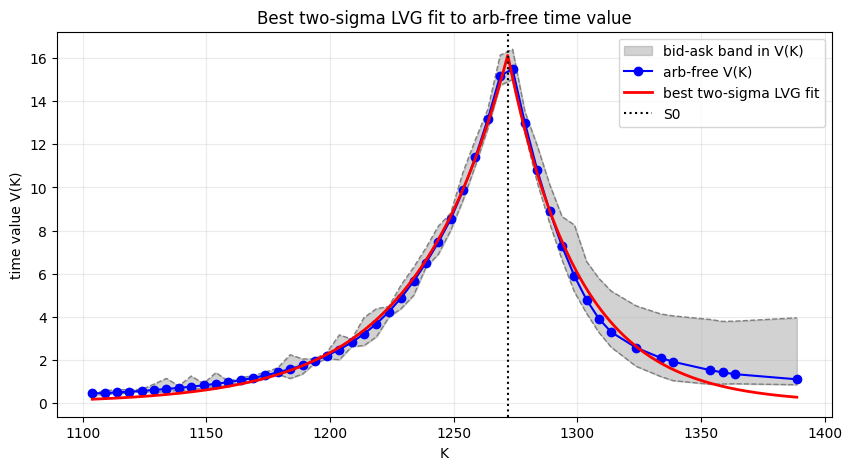

Spot time value implied by fitted lambdas: 16.147574941535662
lambda_left_fit: 2.206292673130081e-14
lambda_right_fit: 1.3630673114397466e-10
J at the fitted two-sigma curve: 6.573672983612577e-05
Optimization success: True
SSE: 4.593807721786276
sigma_left_fit: 37.160227169241665
sigma_right_fit: 28.556488089049186


In [36]:
from scipy.optimize import minimize

# data for the reduced two-sigma approximation
K_arr = np.array(K, dtype=float)
C_arr = np.array(C, dtype=float)
L = 0.0
Kbar = 2000.0

# this is the time value
V_arr = C_arr - np.maximum(S0 - K_arr, 0.0)

def two_sigma_lambdas(sigma_left, sigma_right):
    # solves fort lambdas for the 2-sigma case
    left_distance_at_spot = (S0 - L) / sigma_left
    right_distance_at_spot = (Kbar - S0) / sigma_right

    # values of the two unit-scaled wings at spot
    v1 = np.exp(left_distance_at_spot) - np.exp(-left_distance_at_spot)
    v2 = np.exp(right_distance_at_spot) - np.exp(-right_distance_at_spot)

    # derivative of time-value for left and right wings at spot
    # we do this to match the curves at the spot using the scaling factors lambda (left and right)
    d1 = (np.exp(left_distance_at_spot) + np.exp(-left_distance_at_spot)) / sigma_left
    d2 = -(np.exp(right_distance_at_spot) + np.exp(-right_distance_at_spot)) / sigma_right

    denominator = d1 * v2 - v1 * d2
    lambda_left = v2 / denominator
    lambda_right = v1 / denominator
    value_at_spot = lambda_left * v1

    return lambda_left, lambda_right, value_at_spot


def two_sigma_lvg_V(K_values, sigma_left, sigma_right):
    # AI helped with this
    """
    Two-sigma specialization of the lambda-matched LVG time-value curve.
    The spot value is implied by the sigmas through lambda_left and lambda_right.
    """
    K_values = np.asarray(K_values, dtype=float)
    V_model = np.empty_like(K_values)

    # empty_like is used to create an array of the same shape as K_values to store the model time values
    # more efficient than creating a new array and filling it in a loop

    lambda_left, lambda_right, value_at_spot = two_sigma_lambdas(
        sigma_left, sigma_right
    )

    left_mask = K_values <= S0
    right_mask = K_values > S0
    # boolean arrays

    # left wing
    K_left = K_values[left_mask]
    left_distance = (K_left - L) / sigma_left
    V_model[left_mask] = lambda_left * (
        np.exp(left_distance) - np.exp(-left_distance)
    )

    # right wing
    K_right = K_values[right_mask]
    right_distance = (Kbar - K_right) / sigma_right
    V_model[right_mask] = lambda_right * (
        np.exp(right_distance) - np.exp(-right_distance)
    )

    return V_model


def two_sigma_sse(params):
    # this is the objective function which we minimize to fit the two sigmas to the market time value curve
    # using the sum of squared errors between the model time value and the market time value at the market strikes
    sigma_left, sigma_right = params

    if sigma_left <= 0 or sigma_right <= 0:
        raise ValueError("Sigma values must be positive")

    V_fit_at_market_strikes = two_sigma_lvg_V(
        K_arr,
        sigma_left,
        sigma_right
    )

    if not np.all(np.isfinite(V_fit_at_market_strikes)):
        raise ValueError("Non-finite values in model output, check sigma values")

    return np.sum((V_fit_at_market_strikes - V_arr) ** 2)


# optimize the two sigmas over the finite range displayed in the heatmap
fit_result = minimize(
    two_sigma_sse,
    x0=np.array([50.0, 50.0]),
    method="L-BFGS-B",
    bounds=[(10.0, 500.0), (10.0, 500.0)]
)

sigma_left_fit, sigma_right_fit = fit_result.x
lambda_left_fit, lambda_right_fit, fitted_value_at_spot = two_sigma_lambdas(
    sigma_left_fit, sigma_right_fit
)

# verify that this reduced evaluator uses exactly the lambdas from calculate_J
theta_fit = torch.cat([
    fixed_nu1,
    inverse_softplus([sigma_left_fit]),
    fixed_nu2,
    inverse_softplus([sigma_right_fit]),
])
J_fit, lambda_left_from_J, lambda_right_from_J = calculate_J(
    R1_toy, R2_toy, S0, theta_fit
)
assert np.isclose(lambda_left_fit, lambda_left_from_J.item())
assert np.isclose(lambda_right_fit, lambda_right_from_J.item())

# evaluate fitted curve on a dense strike grid
K_plot = np.linspace(K_arr.min(), K_arr.max(), 1000)
V_fit = two_sigma_lvg_V(K_plot, sigma_left_fit, sigma_right_fit)

K_q, V_bid, V_ask, bid_q, ask_q = load_bid_ask_time_value_band(
    "Quotes.csv",
    S0
)

# plots
plt.figure(figsize=(10, 5))

plt.fill_between(
    K_q,
    V_bid,
    V_ask,
    color="gray",
    alpha=0.35,
    label="bid-ask band in V(K)",
    zorder=1
)

# optional: plot the edges so you can actually see the band
plt.plot(K_q, V_bid, "--", color="gray", linewidth=1, zorder=2)
plt.plot(K_q, V_ask, "--", color="gray", linewidth=1, zorder=2)


plt.plot(K_arr, V_arr, "o-", color="blue", label="arb-free V(K)")
plt.plot(K_plot, V_fit, "-", color="red", linewidth=2, label="best two-sigma LVG fit")
plt.axvline(S0, color="black", linestyle=":", label="S0")

plt.xlabel("K")
plt.ylabel("time value V(K)")
plt.title("Best two-sigma LVG fit to arb-free time value")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()



print("Spot time value implied by fitted lambdas:", fitted_value_at_spot)
print("lambda_left_fit:", lambda_left_fit)
print("lambda_right_fit:", lambda_right_fit)
print("J at the fitted two-sigma curve:", J_fit.item())
print("Optimization success:", fit_result.success)
print("SSE:", fit_result.fun)
print("sigma_left_fit:", sigma_left_fit)
print("sigma_right_fit:", sigma_right_fit)

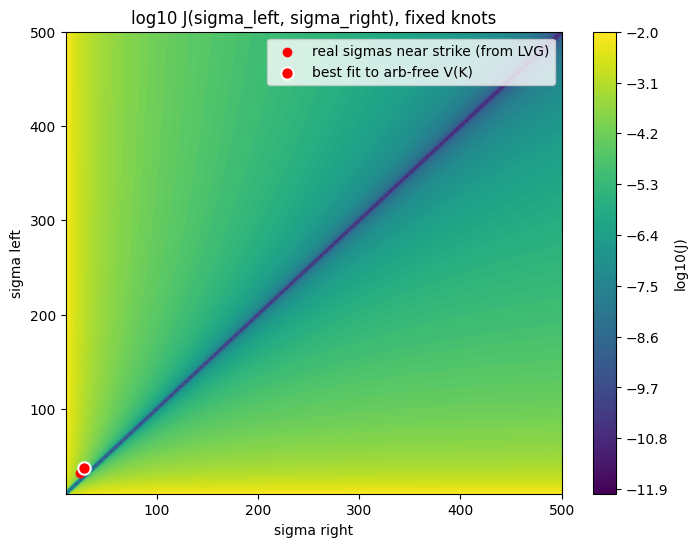

In [37]:
X, Y = np.meshgrid(sigma_right_grid, sigma_left_grid)

plt.figure(figsize=(8, 6))

plt.contourf(
    X,
    Y,
    np.log10(J_values + 1e-12),
    levels=100
)

plt.colorbar(label="log10(J)")
plt.xlabel("sigma right")
plt.ylabel("sigma left")
plt.title("log10 J(sigma_left, sigma_right), fixed knots")
plt.scatter([sigma_right_real], [sigma_left_real], color="red", label="real sigmas near strike (from LVG)")

plt.scatter(
    sigma_right_fit,
    sigma_left_fit,
    color="red",
    s=80,
    edgecolor="white",
    linewidth=1.5,
    label="best fit to arb-free V(K)"
)

plt.legend()

plt.show()



## 7. Conclusion

We see that the 2-sigma approximation looks smooth, but optimizing it does not stay within the bid-ask spread band across all strikes. We can also see in the log smoothness plot that increasing sigmas and keeping them close to eachother generally improves smoothness, but this will generally flatten the LVG curve and not work. We optimized with 2 sigmas, the squared error from each strike, and that is the dot outlined in white. The generic red dot is simply the last 2 sigmas on either side of the spot from the original LVG construction. 

The next natural step is to constrain the optimization now, and that is what file "LVG_fixed_nus_optimization" does.


The next notebook returns to the full many-interval LVG calibration. It keeps the original knot locations (nu) fixed and varies the interval diffusion coefficients (sigma) subject to hard bid-ask constraints. 